In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


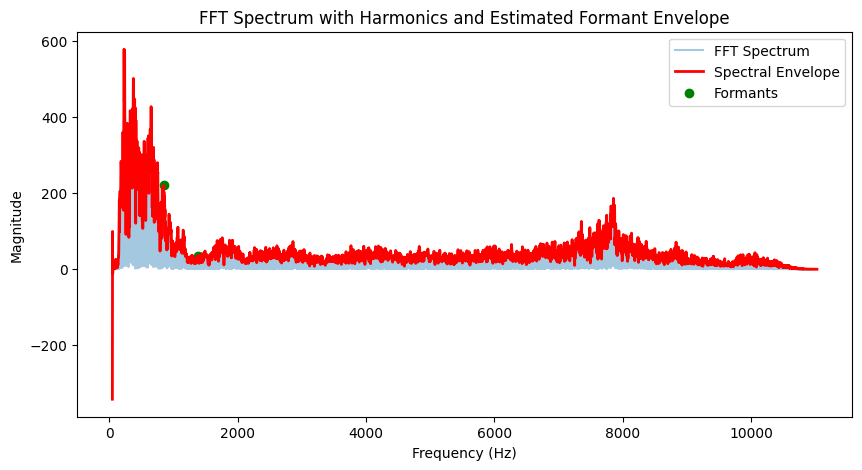

Estimated Pitch (Hz): 212.01923076923077
Formants from FFT (Hz): [ 316.41432599  846.84139083 1389.76715046]


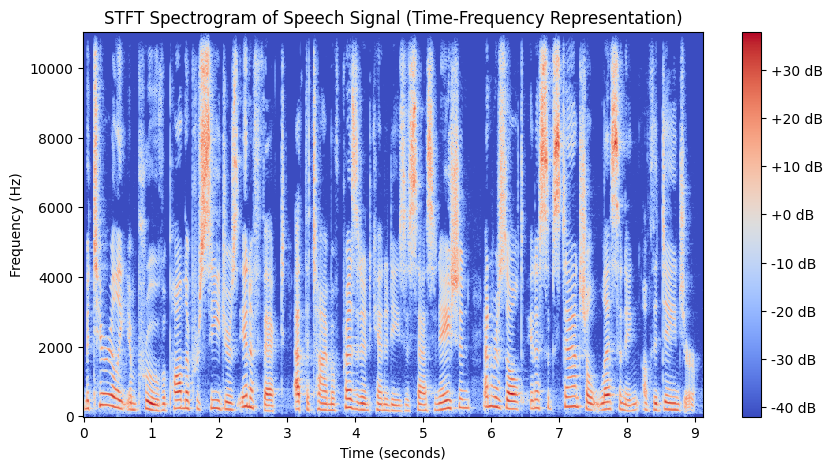

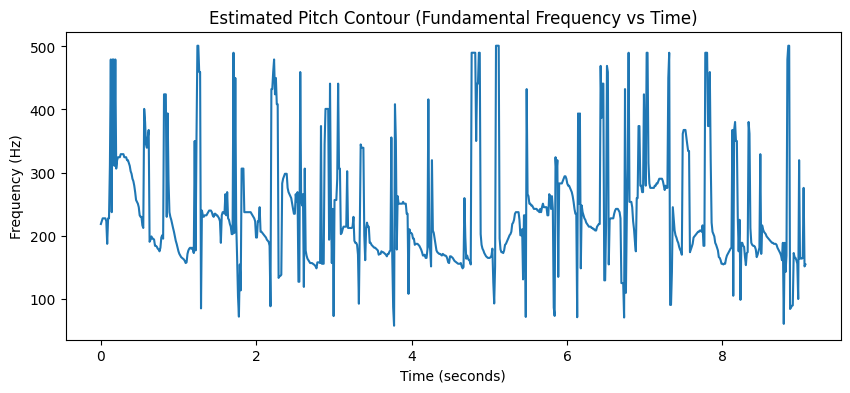

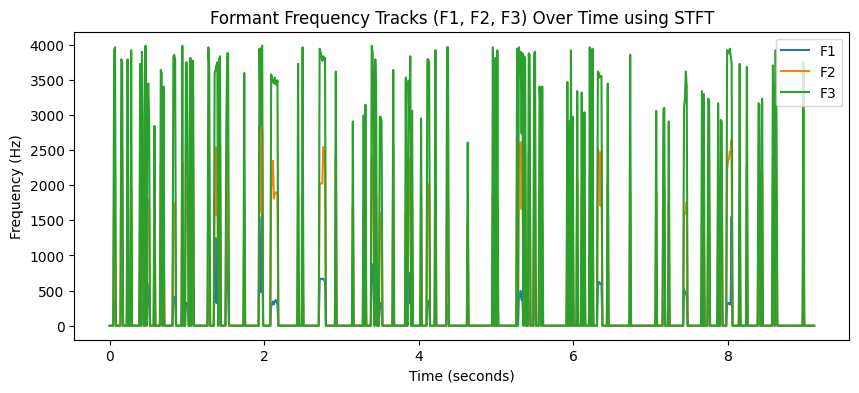

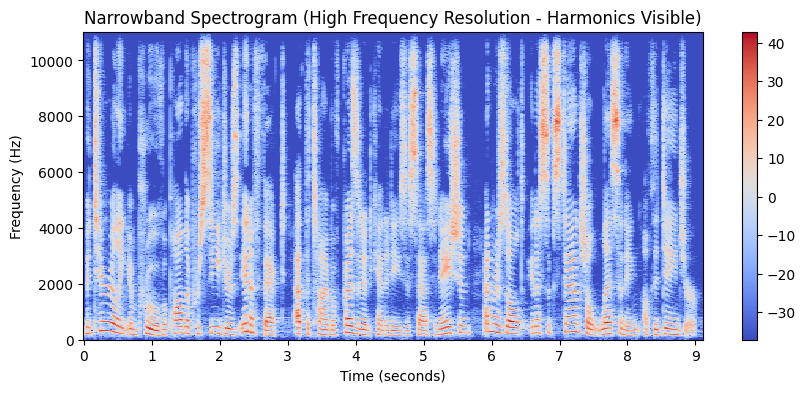

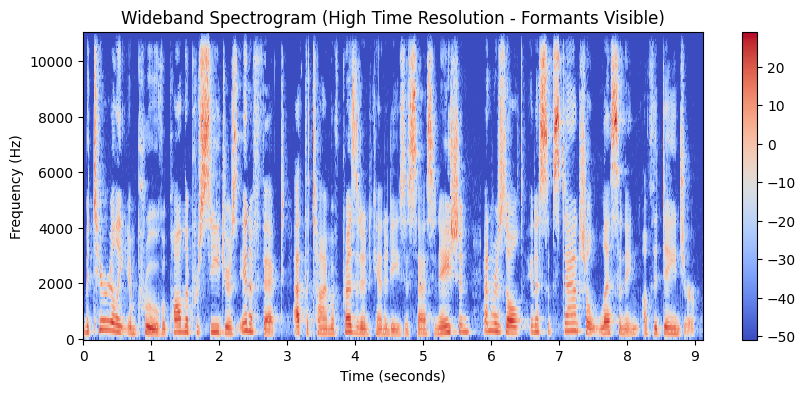

In [ ]:

# FOR JUPYTER / COLAB

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import librosa
import librosa.display
from scipy.interpolate import UnivariateSpline


# 1. LOAD AUDIO

file_path = "/content/drive/MyDrive/SpeechProcessing/Lab6/audio.wav"
y, sr = librosa.load(file_path, sr=None)

y = y / np.max(np.abs(y))


# 2. PITCH FUNCTION (AUTOCORRELATION)

def estimate_pitch(frame, sr):
    corr = np.correlate(frame, frame, mode='full')
    corr = corr[len(corr)//2:]

    min_lag = int(sr / 500)
    max_lag = int(sr / 50)

    corr[:min_lag] = 0

    peak = np.argmax(corr[min_lag:max_lag]) + min_lag

    if peak == 0:
        return 0

    return sr / peak


# 3. FFT ANALYSIS

N = len(y)
fft_spectrum = np.fft.rfft(y)
freqs = np.fft.rfftfreq(N, 1/sr)
magnitude = np.abs(fft_spectrum)

# Remove low-frequency noise
valid_idx = freqs > 50
freqs_f = freqs[valid_idx]
mag_f = magnitude[valid_idx]

# Harmonic peaks
peaks, _ = signal.find_peaks(mag_f, distance=20)
peak_freqs = freqs_f[peaks]
peak_mags = mag_f[peaks]

# Spectral envelope
if len(peak_freqs) > 5:
    spline = UnivariateSpline(peak_freqs, peak_mags, s=0.5)
    envelope = spline(freqs_f)
else:
    envelope = mag_f

# Formants
formant_peaks, _ = signal.find_peaks(envelope, distance=500)
formant_freqs = freqs_f[formant_peaks]
formant_freqs = formant_freqs[(formant_freqs > 300) & (formant_freqs < 4000)]

formants_fft = []
for f in formant_freqs:
    if len(formants_fft) == 0 or abs(f - formants_fft[-1]) > 500:
        formants_fft.append(f)

formants_fft = np.array(formants_fft[:3])

# Pitch (global)
pitch_estimate = estimate_pitch(y, sr)


# FFT PLOT

plt.figure(figsize=(10, 5))
plt.plot(freqs_f, mag_f, alpha=0.4, label="FFT Spectrum")
plt.plot(freqs_f, envelope, 'r', linewidth=2, label="Spectral Envelope")
plt.scatter(formants_fft,
            envelope[np.searchsorted(freqs_f, formants_fft)],
            color='green', label="Formants")

plt.title("FFT Spectrum with Harmonics and Estimated Formant Envelope")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.show()

print("Estimated Pitch (Hz):", pitch_estimate)
print("Formants from FFT (Hz):", formants_fft)


# 4. STFT

n_fft = 1024
hop_length = 256

stft = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
stft_mag = np.abs(stft)
stft_db = librosa.amplitude_to_db(stft_mag)


# SPECTROGRAM

plt.figure(figsize=(10, 5))
librosa.display.specshow(stft_db, sr=sr,
                         hop_length=hop_length,
                         x_axis='time', y_axis='hz')
plt.colorbar(format="%+2.0f dB")

plt.title("STFT Spectrogram of Speech Signal (Time-Frequency Representation)")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.show()


# 5. PITCH CONTOUR

frame_length = 1024
hop_length = 256

pitch_contour = []
times_pitch = []

for i in range(0, len(y) - frame_length, hop_length):
    frame = y[i:i+frame_length]
    pitch = estimate_pitch(frame, sr)
    pitch_contour.append(pitch)
    times_pitch.append(i / sr)

plt.figure(figsize=(10, 4))
plt.plot(times_pitch, pitch_contour)

plt.title("Estimated Pitch Contour (Fundamental Frequency vs Time)")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.show()


# 6. FORMANTS FROM STFT

formants_stft = []

for i in range(stft_mag.shape[1]):
    spectrum = stft_mag[:, i]
    freqs_frame = np.linspace(0, sr/2, len(spectrum))

    valid = freqs_frame > 50
    spectrum = spectrum[valid]
    freqs_frame = freqs_frame[valid]

    peaks, _ = signal.find_peaks(spectrum, distance=5)

    if len(peaks) < 5:
        formants_stft.append([0, 0, 0])
        continue

    peak_freqs = freqs_frame[peaks]
    peak_mags = spectrum[peaks]

    try:
        spline = UnivariateSpline(peak_freqs, peak_mags, s=0.5)
        envelope = spline(freqs_frame)
    except:
        formants_stft.append([0, 0, 0])
        continue

    f_peaks, _ = signal.find_peaks(envelope, distance=50)
    f_freqs = freqs_frame[f_peaks]

    f_freqs = f_freqs[(f_freqs > 300) & (f_freqs < 4000)]

    if len(f_freqs) >= 3:
        formants_stft.append(f_freqs[:3])
    else:
        formants_stft.append([0, 0, 0])

formants_stft = np.array(formants_stft)

# FIXED TIME AXIS
times_stft = librosa.frames_to_time(
    np.arange(len(formants_stft)),
    sr=sr,
    hop_length=hop_length
)

plt.figure(figsize=(10, 4))
plt.plot(times_stft, formants_stft[:, 0], label="F1")
plt.plot(times_stft, formants_stft[:, 1], label="F2")
plt.plot(times_stft, formants_stft[:, 2], label="F3")

plt.title("Formant Frequency Tracks (F1, F2, F3) Over Time using STFT")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.legend()
plt.show()


# 7. NARROWBAND

n_fft_narrow = 2048
stft_narrow = librosa.stft(y, n_fft=n_fft_narrow, hop_length=512)

plt.figure(figsize=(10, 4))
librosa.display.specshow(librosa.amplitude_to_db(np.abs(stft_narrow)),
                         sr=sr, hop_length=512,
                         x_axis='time', y_axis='hz')
plt.title("Narrowband Spectrogram (High Frequency Resolution - Harmonics Visible)")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.colorbar()
plt.show()


# 8. WIDEBAND

n_fft_wide = 256
stft_wide = librosa.stft(y, n_fft=n_fft_wide, hop_length=64)

plt.figure(figsize=(10, 4))
librosa.display.specshow(librosa.amplitude_to_db(np.abs(stft_wide)),
                         sr=sr, hop_length=64,
                         x_axis='time', y_axis='hz')
plt.title("Wideband Spectrogram (High Time Resolution - Formants Visible)")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.colorbar()
plt.show()

✔ FFT
Harmonics clearly visible
Formants estimated from spectral envelope

---


✔ STFT
Pitch appears as horizontal harmonic structure
Formants appear as energy bands

---


✔ Narrowband vs Wideband
Narrowband → harmonics clearer
Wideband → formants clearer

---


✔ Limitation
Formants slightly inaccurate due to absence of LPC
Envelope-based method is an approximation